# AQI Forecasting - EDA

Delhi AQI, pollutant and weather data from 2022-2025.

The main aim is to understand the data and identify useful patterns for the 48-hour winter AQI spike prediction problem.

In [10]:
# Load processed data.
import pandas as pd

final = pd.read_csv("../processed_data/delhi_6station_avg_2022_2025.csv", index_col="Timestamp", parse_dates=True)
final.shape

(35040, 25)

## 1. Load data

Load the processed 6-station average dataset and check its size.

In [11]:
# EDA imports.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

final = pd.read_csv("../processed_data/delhi_6station_avg_2022_2025.csv", index_col="Timestamp", parse_dates=True)


## 2. Daily AQI trend

Daily mean AQI is plotted to see the overall time pattern.

A clear winter rise and lower values during the monsoon period can be seen.

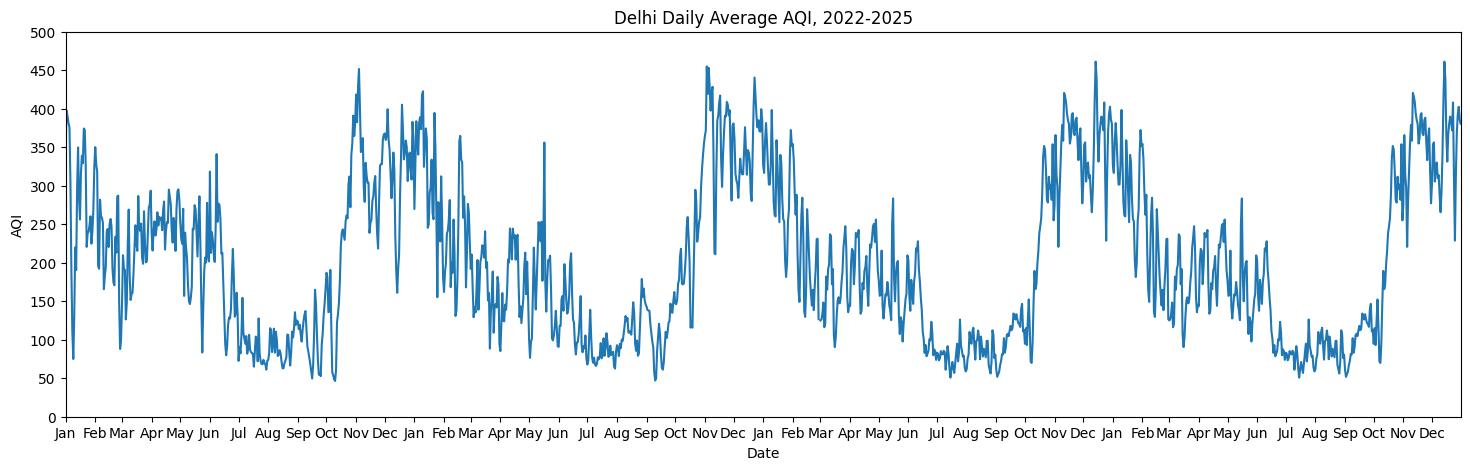

In [12]:
# Daily AQI trend.
ax = final['AQI'].resample('D').mean().plot(figsize=(18,5))

plt.title("Delhi Daily Average AQI, 2022-2025")
plt.ylabel("AQI")
plt.xlabel("Date")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xticks(rotation=0)
plt.yticks(range(0, 501, 50))

plt.show()

## 3. AQI distribution

The histogram shows how AQI values are distributed.

Most observations are at lower values, with fewer very high AQI values.

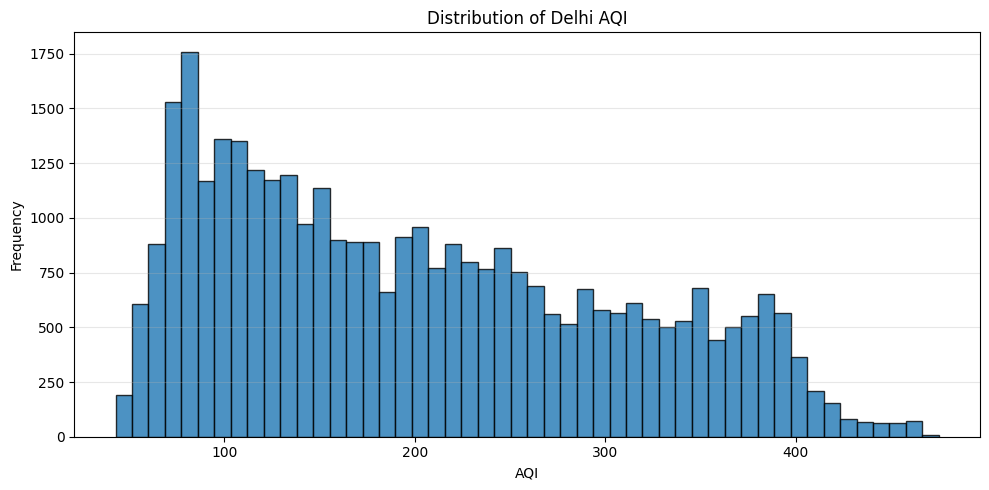

In [13]:
# AQI distribution.


final['AQI'].plot(kind='hist', bins=50, figsize=(10,5),edgecolor='black', alpha=0.8)

plt.title("Distribution of Delhi AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



## 4. Monthly AQI trend

Monthly averages make the seasonal pattern easier to see.

AQI is generally higher in winter and lower during the summer/monsoon months.

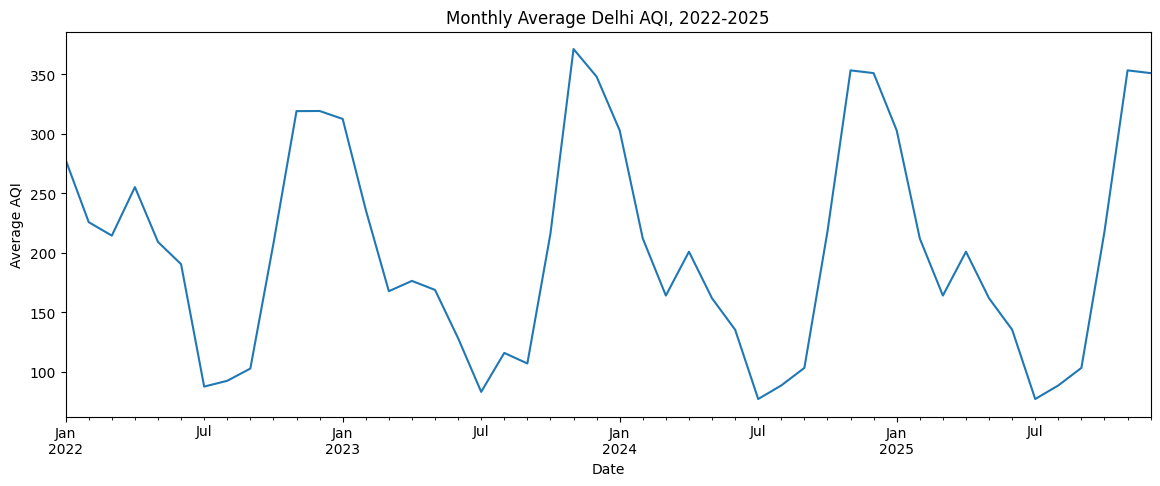

In [14]:
# Monthly AQI trend.

monthly_aqi = final['AQI'].resample('ME').mean()

monthly_aqi.plot(figsize=(14,5))

plt.title("Monthly Average Delhi AQI, 2022-2025")
plt.xlabel("Date")
plt.ylabel("Average AQI")

plt.show()

## 5. Missing values

Highly sparse columns are removed first. The remaining missing numeric values are filled using the median.

In [15]:
# Handle missing values.

final = final.dropna(axis=1, thresh=len(final) * 0.10)
final = final.fillna(final.median(numeric_only=True))
final.isnull().sum()

PM2.5 (µg/m³)      0
PM10 (µg/m³)       0
NO (µg/m³)         0
NO2 (µg/m³)        0
NOx (ppb)          0
NH3 (µg/m³)        0
SO2 (µg/m³)        0
CO (mg/m³)         0
Ozone (µg/m³)      0
Benzene (µg/m³)    0
Toluene (µg/m³)    0
AT (°C)            0
RH (%)             0
WS (m/s)           0
WD (deg)           0
RF (mm)            0
TOT-RF (mm)        0
SR (W/mt2)         0
BP (mmHg)          0
VWS (m/s)          0
AQI                0
dtype: int64

### Save cleaned data

Save the cleaned dataset so it can be reused in later steps.

In [16]:
# Save cleaned data.

final.to_csv("../processed_data/delhi_6station_avg_2022_2025_cleaned.csv")

## 6. PM2.5 vs PM10

Monthly PM2.5 and PM10 are compared to see whether they follow a similar pattern.

Both show a strong seasonal pattern, with higher values in winter.

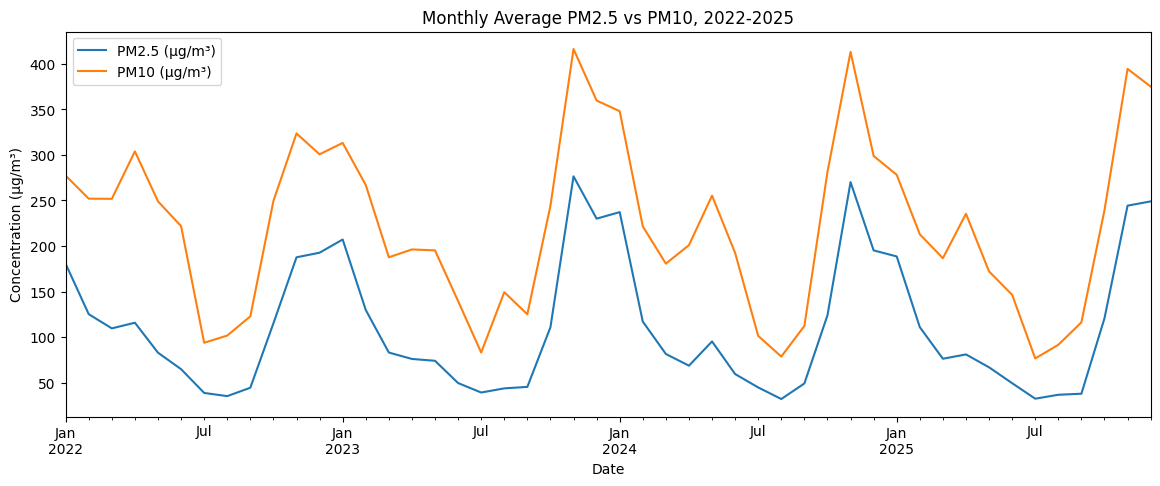

In [17]:
# Compare PM2.5 and PM10.
monthly_pm = final[['PM2.5 (µg/m³)', 'PM10 (µg/m³)']].resample('ME').mean()

monthly_pm.plot(figsize=(14,5))

plt.title("Monthly Average PM2.5 vs PM10, 2022-2025")
plt.xlabel("Date")
plt.ylabel("Concentration (µg/m³)")

plt.show()

## 7. Correlation with AQI

Check the correlation of each feature with AQI.

PM2.5 and PM10 show the strongest positive relationships among the main pollutants, while temperature shows a negative relationship.

In [18]:
# Correlation with AQI.
final.corr()['AQI'].sort_values(ascending=False)

AQI                1.000000
PM2.5 (µg/m³)      0.752234
PM10 (µg/m³)       0.731591
NH3 (µg/m³)        0.537303
NO2 (µg/m³)        0.525306
CO (mg/m³)         0.449822
NOx (ppb)          0.447911
NO (µg/m³)         0.379044
Toluene (µg/m³)    0.280010
Benzene (µg/m³)    0.261621
WD (deg)           0.169869
SO2 (µg/m³)        0.133632
VWS (m/s)          0.130384
BP (mmHg)          0.053967
RH (%)            -0.012016
Ozone (µg/m³)     -0.036271
TOT-RF (mm)       -0.039563
SR (W/mt2)        -0.041693
RF (mm)           -0.076181
WS (m/s)          -0.142663
AT (°C)           -0.505112
Name: AQI, dtype: float64

## 8. AQI lag analysis

Create AQI values from 24, 48 and 72 hours earlier.

These help check how strongly current AQI depends on its recent past.

In [19]:
# Past AQI lags.
final['AQI_24h'] = final['AQI'].shift(freq='24h')
final['AQI_48h'] = final['AQI'].shift(freq='48h')
final['AQI_72h'] = final['AQI'].shift(freq='72h')

final[['AQI', 'AQI_24h', 'AQI_48h', 'AQI_72h']].corr()['AQI']

AQI        1.000000
AQI_24h    0.911738
AQI_48h    0.848826
AQI_72h    0.815205
Name: AQI, dtype: float64

## 9. Winter weather analysis

Winter is taken as November, December, January and February.

Future AQI values are created here for analysis of whether current conditions are followed by higher AQI.

In [20]:
# Future AQI for winter analysis.

final['AQI_24h_ahead'] = final['AQI'].shift(freq='-24h')
final['AQI_48h_ahead'] = final['AQI'].shift(freq='-48h')
final['AQI_72h_ahead'] = final['AQI'].shift(freq='-72h')

winter = final[final.index.month.isin([11, 12, 1, 2])]

winter[['WS (m/s)', 'AQI_24h_ahead']].corr()

winter[['AT (°C)', 'WS (m/s)', 'RH (%)', 'WD (deg)',
        'BP (mmHg)', 'SR (W/mt2)', 'RF (mm)', 'TOT-RF (mm)',
        'AQI_24h_ahead']].corr()['AQI_24h_ahead'].sort_values(ascending=False)

AQI_24h_ahead    1.000000
RH (%)           0.145616
AT (°C)          0.061963
SR (W/mt2)       0.033826
RF (mm)         -0.053723
WD (deg)        -0.073206
TOT-RF (mm)     -0.075203
BP (mmHg)       -0.107017
WS (m/s)        -0.250785
Name: AQI_24h_ahead, dtype: float64

## 10. Weather vs future AQI

Compare winter weather conditions with AQI 24, 48 and 72 hours later.

Wind speed shows the clearest relationship among the weather variables tested.

In [21]:
# Weather vs future AQI.
weather = ['AT (°C)', 'WS (m/s)', 'RH (%)', 'WD (deg)',
           'BP (mmHg)', 'SR (W/mt2)', 'RF (mm)', 'TOT-RF (mm)']

winter[weather + ['AQI_24h_ahead', 'AQI_48h_ahead', 'AQI_72h_ahead']].corr().loc[
    weather, ['AQI_24h_ahead', 'AQI_48h_ahead', 'AQI_72h_ahead']
]

,AQI_24h_ahead,AQI_48h_ahead,AQI_72h_ahead
AT (°C),0.061963,0.048963,0.046286
WS (m/s),-0.250785,-0.226425,-0.210629
RH (%),0.145616,0.093290,0.063380
WD (deg),-0.073206,-0.011485,0.030678
BP (mmHg),-0.107017,-0.101457,-0.102294
SR (W/mt2),0.033826,0.048313,0.046297
RF (mm),-0.053723,-0.043136,-0.027571
TOT-RF (mm),-0.075203,-0.064867,-0.040437


## 11. Future AQI change

Calculate how much AQI changes over the next 48 and 72 hours.

This shifts the focus from AQI level to sudden increases.

In [22]:
# Future AQI change.
final['AQI_change_48h'] = final['AQI'].shift(freq='-48h') - final['AQI']
final['AQI_change_72h'] = final['AQI'].shift(freq='-72h') - final['AQI']

winter = final[final.index.month.isin([11, 12, 1, 2])]

winter[['AQI_change_48h', 'AQI_change_72h']].describe()

,AQI_change_48h,AQI_change_72h
count,11448.000000,11424.000000
mean,-2.993449,-4.745973
std,73.770153,82.011703
min,-264.000000,-323.000000
25%,-50.000000,-58.000000
50%,-3.000000,-5.000000
75%,47.000000,47.000000
max,267.000000,281.000000


## 12. Winter AQI change distribution

The histogram shows the distribution of 48-hour AQI changes in winter.

Large positive changes are relatively uncommon.

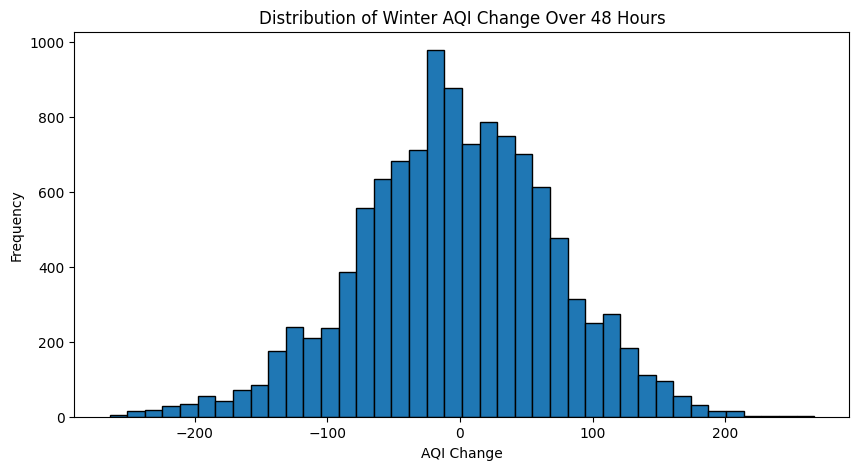

In [23]:
# Winter AQI change distribution.
winter['AQI_change_48h'].plot(kind='hist', bins=40, figsize=(10,5), edgecolor='black')

plt.title("Distribution of Winter AQI Change Over 48 Hours")
plt.xlabel("AQI Change")
plt.ylabel("Frequency")

plt.show()

## 13. AQI spike thresholds

The 95th percentile is used as a starting point for defining a large increase.

- 48h: +118 AQI
- 72h: +134 AQI

In [24]:
# Spike thresholds.
winter['AQI_change_48h'].quantile([0.90, 0.95, 0.99])
winter['AQI_change_72h'].quantile([0.90, 0.95, 0.99])

0.90    102.00
0.95    134.00
0.99    182.77
Name: AQI_change_72h, dtype: float64

## 14. Weather conditions before 48-hour spikes

Compare average weather conditions during spike and non-spike periods.

Lower wind speed is the main difference seen here.

In [25]:
# 48h spike conditions.
winter = winter.copy()

winter['spike_48h'] = winter['AQI_change_48h'] >= 118

winter.groupby('spike_48h')[
    ['AT (°C)', 'WS (m/s)', 'RH (%)', 'BP (mmHg)']
].mean()

,AT (°C),WS (m/s),RH (%),BP (mmHg)
spike_48h,,,,
False,17.571716,0.771224,68.777446,913.682719
True,16.960266,0.671286,68.527472,915.454627


## 15. Temperature-change check

Check whether a rapid 24-hour temperature drop occurs before a spike.

The comparison does not show a clear temperature-drop pattern before the spikes.

In [26]:
final['AQI_change_48h'] = final['AQI'].shift(freq='-48h') - final['AQI']
final['Temp_change_24h'] = final['AT (°C)'] - final['AT (°C)'].shift(freq='24h')

winter = final[final.index.month.isin([11, 12, 1, 2])].copy()
winter['spike_48h'] = winter['AQI_change_48h'] >= 118

winter.groupby('spike_48h')[
    ['AT (°C)', 'Temp_change_24h', 'WS (m/s)', 'RH (%)', 'BP (mmHg)']
].mean()

,AT (°C),Temp_change_24h,WS (m/s),RH (%),BP (mmHg)
spike_48h,,,,,
False,17.571716,-0.065038,0.771224,68.777446,913.682719
True,16.960266,0.053429,0.671286,68.527472,915.454627


## 16. Previous PM2.5 and PM10

Check pollutant levels 24, 48 and 72 hours before a 48-hour spike.

The spike periods have lower average previous PM2.5 and PM10 levels in this dataset.

In [27]:
# Previous PM2.5 and PM10.
for col in ['PM2.5 (µg/m³)', 'PM10 (µg/m³)']:
    final[col + '_24h'] = final[col].shift(freq='24h')
    final[col + '_48h'] = final[col].shift(freq='48h')
    final[col + '_72h'] = final[col].shift(freq='72h')

winter = final[final.index.month.isin([11, 12, 1, 2])].copy()

winter['spike_48h'] = winter['AQI_change_48h'] >= 118

winter.groupby('spike_48h')[
    ['PM2.5 (µg/m³)_24h', 'PM2.5 (µg/m³)_48h', 'PM2.5 (µg/m³)_72h',
     'PM10 (µg/m³)_24h', 'PM10 (µg/m³)_48h', 'PM10 (µg/m³)_72h']
].mean()

,PM2.5 (µg/m³)_24h,PM2.5 (µg/m³)_48h,PM2.5 (µg/m³)_72h,PM10 (µg/m³)_24h,PM10 (µg/m³)_48h,PM10 (µg/m³)_72h
spike_48h,,,,,,
False,201.834492,201.370835,200.835412,322.950720,322.661335,321.807619
True,141.972089,168.121321,187.708623,238.180182,274.002297,305.064188


## 17. Conditions before 72-hour spikes

Repeat the spike comparison for the 72-hour target to see whether the pattern changes with a longer forecast window.

In [28]:
# 72h spike conditions.
winter['spike_72h'] = winter['AQI_change_72h'] >= 134

winter.groupby('spike_72h')[
    ['AQI', 'AT (°C)', 'WS (m/s)',
     'PM2.5 (µg/m³)', 'PM10 (µg/m³)']
].mean()

,AQI,AT (°C),WS (m/s),PM2.5 (µg/m³),PM10 (µg/m³)
spike_72h,,,,,
False,309.382036,17.524298,0.769338,199.743243,319.610121
True,207.746528,17.848470,0.705034,161.107364,269.205990


## 18. Rebuild spike flags

Recreate the winter spike columns before the statistical test so the groups are based on the current data.

In [29]:
# Rebuild spike columns.
final['AQI_change_48h'] = final['AQI'].shift(freq='-48h') - final['AQI']
final['AQI_change_72h'] = final['AQI'].shift(freq='-72h') - final['AQI']

winter = final[final.index.month.isin([11, 12, 1, 2])].copy()

winter['spike_48h'] = winter['AQI_change_48h'] >= 118


## 19. Statistical significance test

Welch's t-test is used to check the difference between spike and non-spike groups.

Wind speed is statistically significant; pressure is not.

In [30]:
# Welch's t-test.
from scipy.stats import ttest_ind

spike = winter[winter['spike_48h'] == True]
normal = winter[winter['spike_48h'] == False]

wind_test = ttest_ind(
    spike['WS (m/s)'],
    normal['WS (m/s)'],
    equal_var=False,
    nan_policy='omit'
)

pressure_test = ttest_ind(
    spike['BP (mmHg)'],
    normal['BP (mmHg)'],
    equal_var=False,
    nan_policy='omit'
)

print("Wind speed:", wind_test)
print("Pressure:", pressure_test)

Wind speed: TtestResult(statistic=np.float64(-5.908481100606531), pvalue=np.float64(5.199567742758859e-09), df=np.float64(763.4671476689565))
Pressure: TtestResult(statistic=np.float64(1.6075334152868834), pvalue=np.float64(0.10840323491133633), df=np.float64(677.603000345692))


## 20. Autocorrelation (ACF)

ACF shows how strongly AQI is related to its past values across different time lags.

The correlation stays high across the 7-day range, showing strong persistence in AQI.

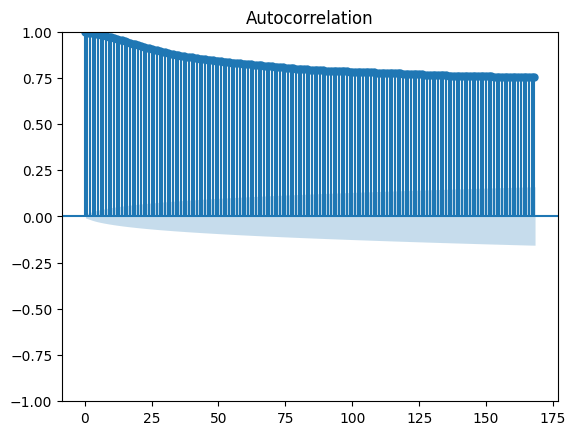

In [31]:
# ACF over one week.
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(final['AQI'], lags=168)

plt.show()

## 21. Outlier check

Use a boxplot and the actual minimum/maximum values to check for unusual readings.

PM2.5 ranges from 1.33 to 976.5 µg/m³. No negative values were found, so the high values were kept as valid extreme pollution observations.

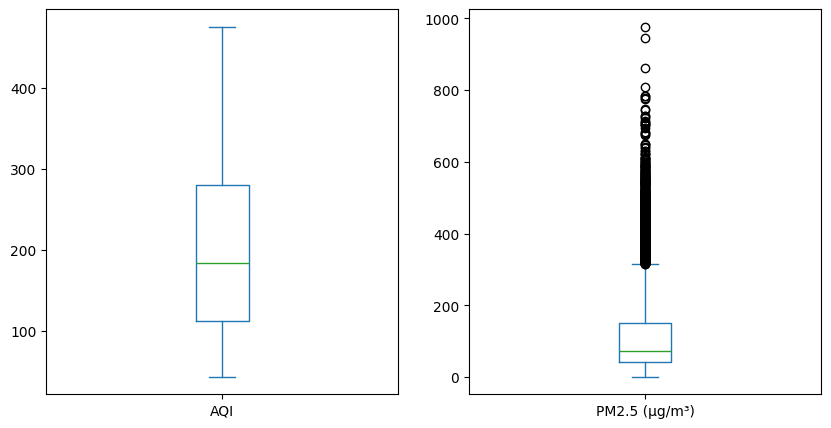

count    35040.000000
mean       110.838210
std         96.553681
min          1.333333
25%         42.416667
50%         74.131944
75%        152.196250
max        976.500000
Name: PM2.5 (µg/m³), dtype: float64

In [32]:
# Outlier check.
final[['AQI', 'PM2.5 (µg/m³)']].plot(kind='box', subplots=True, figsize=(10,5))
plt.show()
final['PM2.5 (µg/m³)'].describe()

## 22. Feature engineering

Create a small set of lag, rolling and time features based on the patterns found in EDA.

Only information available at the prediction time should be used as an input feature.

In [33]:
final['AQI_3d_mean'] = final['AQI'].rolling('72h').mean()

In [34]:
for col in ['PM2.5 (µg/m³)', 'PM10 (µg/m³)']:
    final[col + '_24h'] = final[col].shift(freq='24h')
    final[col + '_48h'] = final[col].shift(freq='48h')
    final[col + '_72h'] = final[col].shift(freq='72h')

In [35]:
for lag in ['24h', '48h', '72h']:
    final['WS_' + lag] = final['WS (m/s)'].shift(freq=lag)

In [36]:
import numpy as np

# Wind lags.
for lag in ['24h', '48h', '72h']:
    final['WS_' + lag] = final['WS (m/s)'].shift(freq=lag)

# Time features.
final['hour'] = final.index.hour
final['month'] = final.index.month
final['day_of_week'] = final.index.dayofweek

# Hour cycle.
final['hour_sin'] = np.sin(2 * np.pi * final['hour'] / 24)
final['hour_cos'] = np.cos(2 * np.pi * final['hour'] / 24)

# Month cycle.
final['month_sin'] = np.sin(2 * np.pi * final['month'] / 12)
final['month_cos'] = np.cos(2 * np.pi * final['month'] / 12)

In [37]:
final = final.drop(columns=['hour', 'month'])

In [38]:
winter['spike_48h'] = winter['AQI_change_48h'] >= 118
winter['spike_72h'] = winter['AQI_change_72h'] >= 134

print("48h spike percentage:")
print(winter['spike_48h'].mean() * 100)

print("\n72h spike percentage:")
print(winter['spike_72h'].mean() * 100)

48h spike percentage:
5.104166666666667

72h spike percentage:
5.0


## 23. Define the target

The main target is a large AQI increase within the next 48 hours.

The 72-hour target is kept for comparison.

In [39]:
final['target_48h'] = final['AQI_change_48h'] >= 118
final['target_72h'] = final['AQI_change_72h'] >= 134

In [40]:
print("48h target:")
print(final['target_48h'].value_counts(normalize=True) * 100)

print("\n72h target:")
print(final['target_72h'].value_counts(normalize=True) * 100)

48h target:
target_48h
False    97.634132
True      2.365868
Name: proportion, dtype: float64

72h target:
target_72h
False    97.88242
True      2.11758
Name: proportion, dtype: float64


## 24. Prepare features and target

Separate the model inputs (`X`) from the target (`y`).

Future-looking columns are removed here to avoid data leakage.

In [41]:
# 48h spike target.
y = final['target_48h']

# Remove future-looking columns.
X = final.drop(columns=[
    'AQI_24h_ahead', 'AQI_48h_ahead','AQI_72h_ahead','AQI_change_48h','AQI_change_72h','target_48h', 'target_72h'
])

In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35040, 40)
y shape: (35040,)


In [43]:
valid = final['AQI_change_48h'].notna() & X.notna().all(axis=1)

X = X.loc[valid]
y = y.loc[valid]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34824, 40)
y shape: (34824,)


## 25. Winter-only model data and time split

Use the winter months for the spike model and keep the split chronological:

- 2022-2023: train
- 2024: validation
- 2025: test

In [44]:
# Winter model data.
winter_model = final[final.index.month.isin([11, 12, 1, 2])].copy()
winter_model = winter_model[winter_model['AQI_change_48h'].notna()]

# Features and target.
y = winter_model['target_48h']
X = winter_model.drop(columns=[
    'AQI_24h_ahead', 'AQI_48h_ahead', 'AQI_72h_ahead',
    'AQI_change_48h', 'AQI_change_72h',
    'target_48h', 'target_72h'
])

# Time split.
train = X.index.year <= 2023
val = X.index.year == 2024
test = X.index.year == 2025

X_train, y_train = X[train], y[train]
X_val, y_val = X[val], y[val]
X_test, y_test = X[test], y[test]

print(X_train.shape, X_val.shape, X_test.shape)

(5760, 40) (2856, 40) (2832, 40)


In [45]:
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
target_48h
False    5434
True      326
Name: count, dtype: int64

Validation:
target_48h
False    2725
True      131
Name: count, dtype: int64

Test:
target_48h
False    2701
True      131
Name: count, dtype: int64


In [46]:
print(X_train.isna().sum().sum())
print(X_val.isna().sum().sum())
print(X_test.isna().sum().sum())

600
0
0


In [47]:
train_valid = X_train.notna().all(axis=1)

X_train = X_train[train_valid]
y_train = y_train[train_valid]

print(X_train.shape, y_train.shape)

(5688, 40) (5688,)
